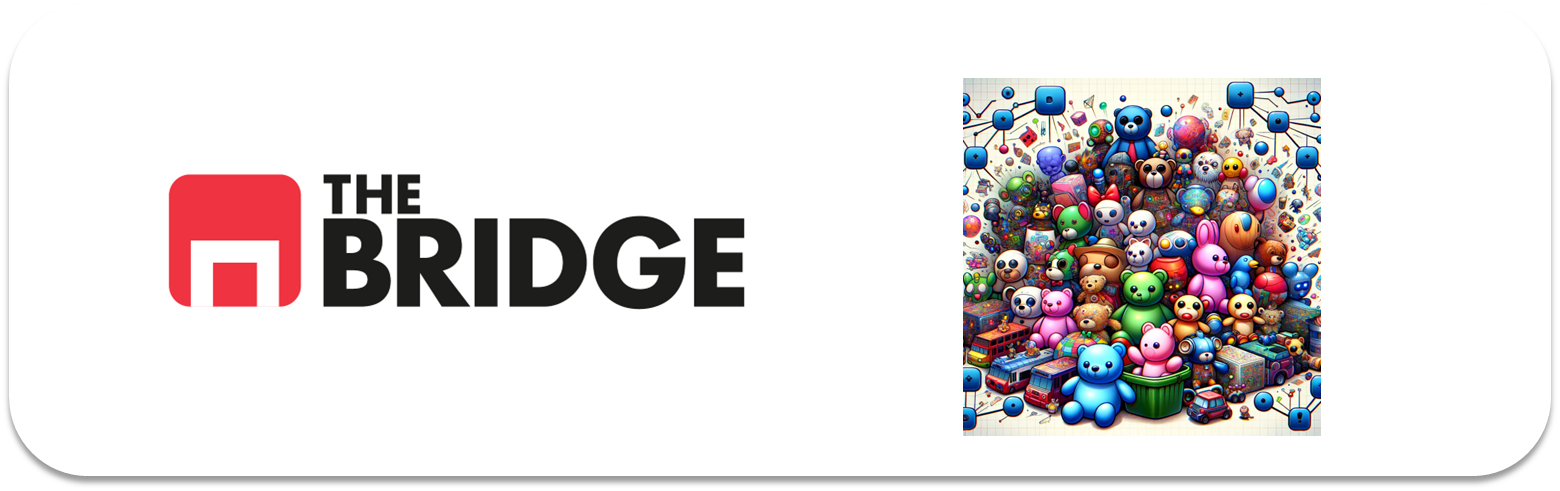

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


In [3]:

df = pd.read_csv("./data/empowering_drinks.csv", sep="|")
df.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [5]:
df.columns

Index(['Azúcares', 'Vitamínas del grupo B', 'Cafeína', 'Ácido Cítrico',
       'Taurina'],
      dtype='str')

In [ ]:
df.shape

(153, 5)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Azúcares,153.0,0.019231,1.026182,-2.434235,-0.816038,0.061000,0.876275,2.259772
Vitamínas del grupo B,153.0,0.037273,0.995984,-3.679162,-0.499016,-0.023821,0.707247,3.156325
Cafeína,153.0,0.041057,1.040928,-1.695971,-1.043392,0.211566,0.894264,3.062832
Ácido Cítrico,153.0,0.080022,1.009450,-1.493188,-0.738463,-0.165254,0.917474,2.971473
Taurina,153.0,-0.044088,0.934399,-1.634288,-0.799428,-0.154899,0.493956,2.431870


In [8]:
df.isnull().sum()

Azúcares                 0
Vitamínas del grupo B    0
Cafeína                  0
Ácido Cítrico            0
Taurina                  0
dtype: int64

In [11]:
df.duplicated().sum()

0

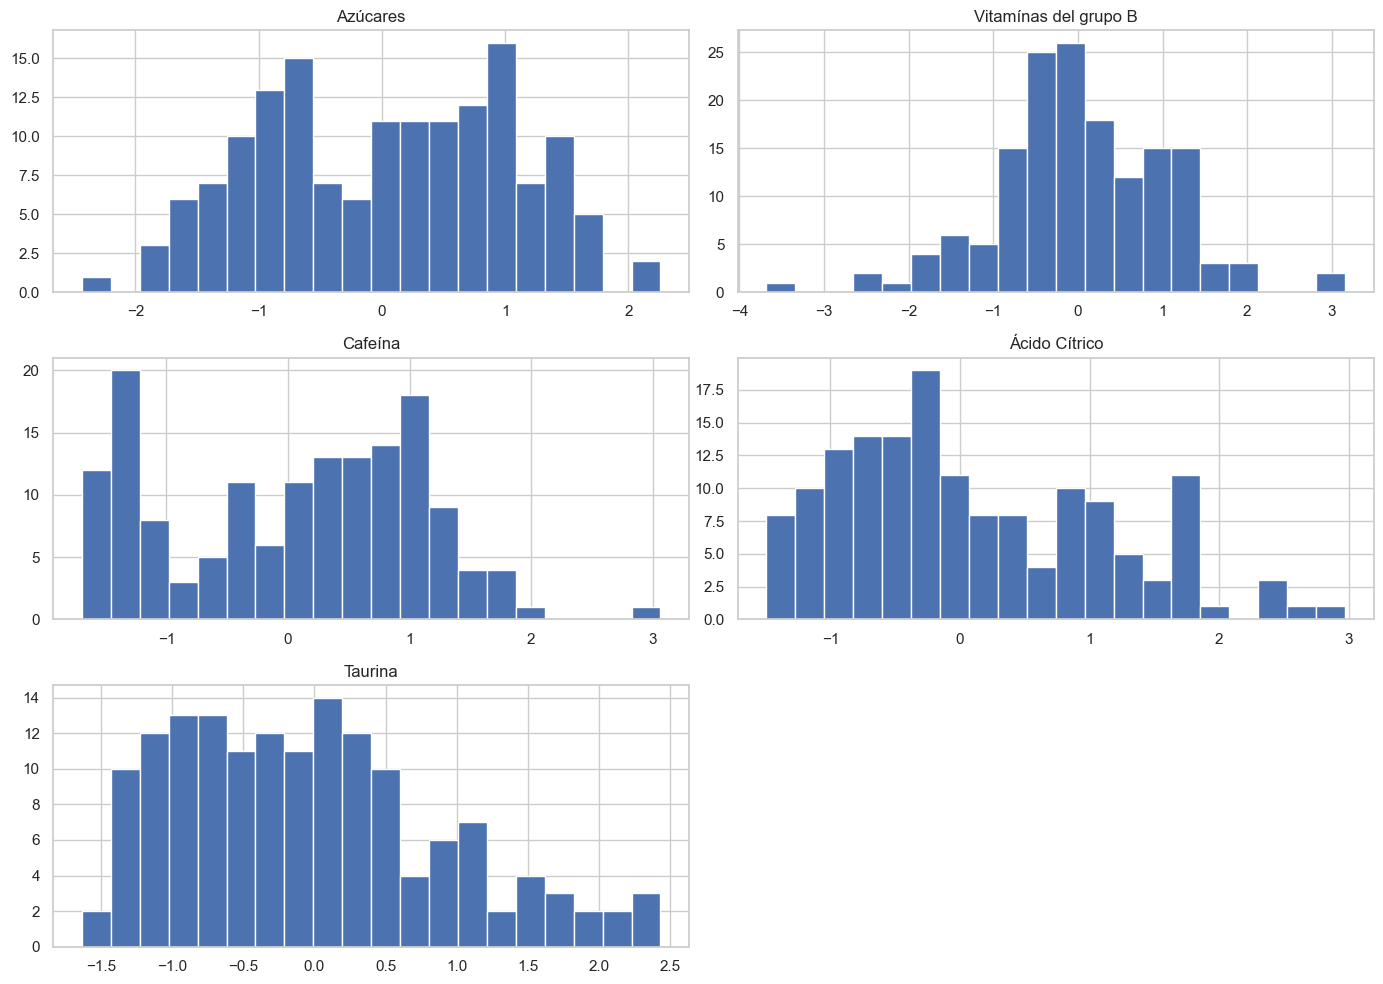

In [12]:
df.hist(bins=20, figsize=(14, 10))
plt.tight_layout()
plt.show()

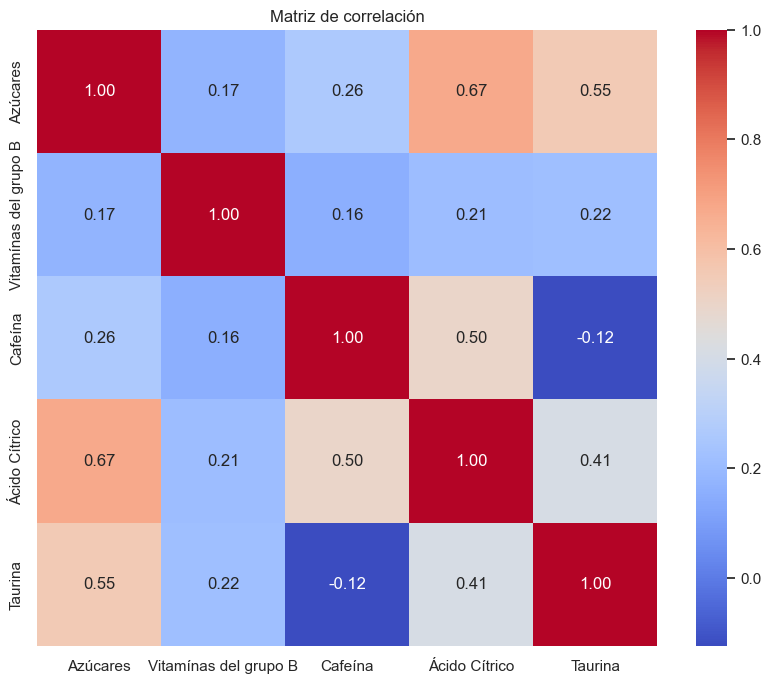

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

In [14]:
X = df.select_dtypes(include=np.number).copy()
X.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [15]:
low_var_cols = X.columns[X.std() < 1e-6]
low_var_cols

Index([], dtype='str')

In [16]:
X = X.drop(columns=low_var_cols, errors="ignore")

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.465925,0.196207,0.957824,0.927289,0.317612
1,0.221992,-0.871612,0.667526,0.879813,-0.267608
2,0.173684,1.079919,1.132002,1.307094,0.336190
3,1.635003,0.453956,1.373917,2.240782,1.320844
4,0.270301,1.816346,0.599790,-0.117176,-0.295475


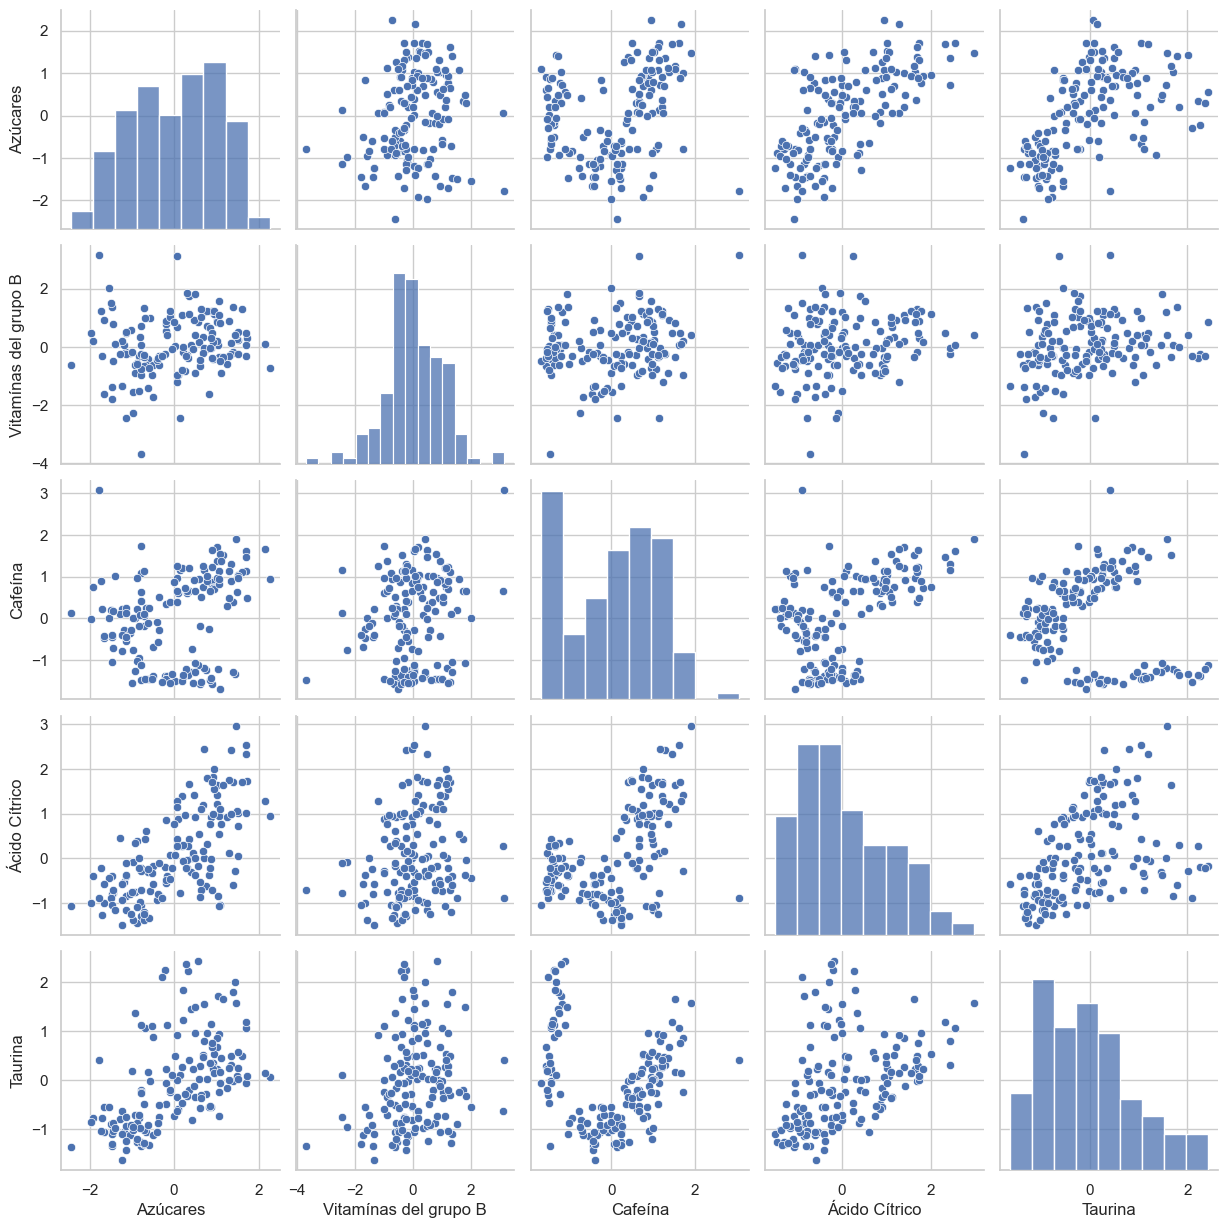

In [19]:
sns.pairplot(X.sample(min(len(X), 200)))
plt.show()

In [20]:
top_vars = X.var().sort_values(ascending=False).head(4).index.tolist()
top_vars

['Cafeína', 'Azúcares', 'Ácido Cítrico', 'Vitamínas del grupo B']

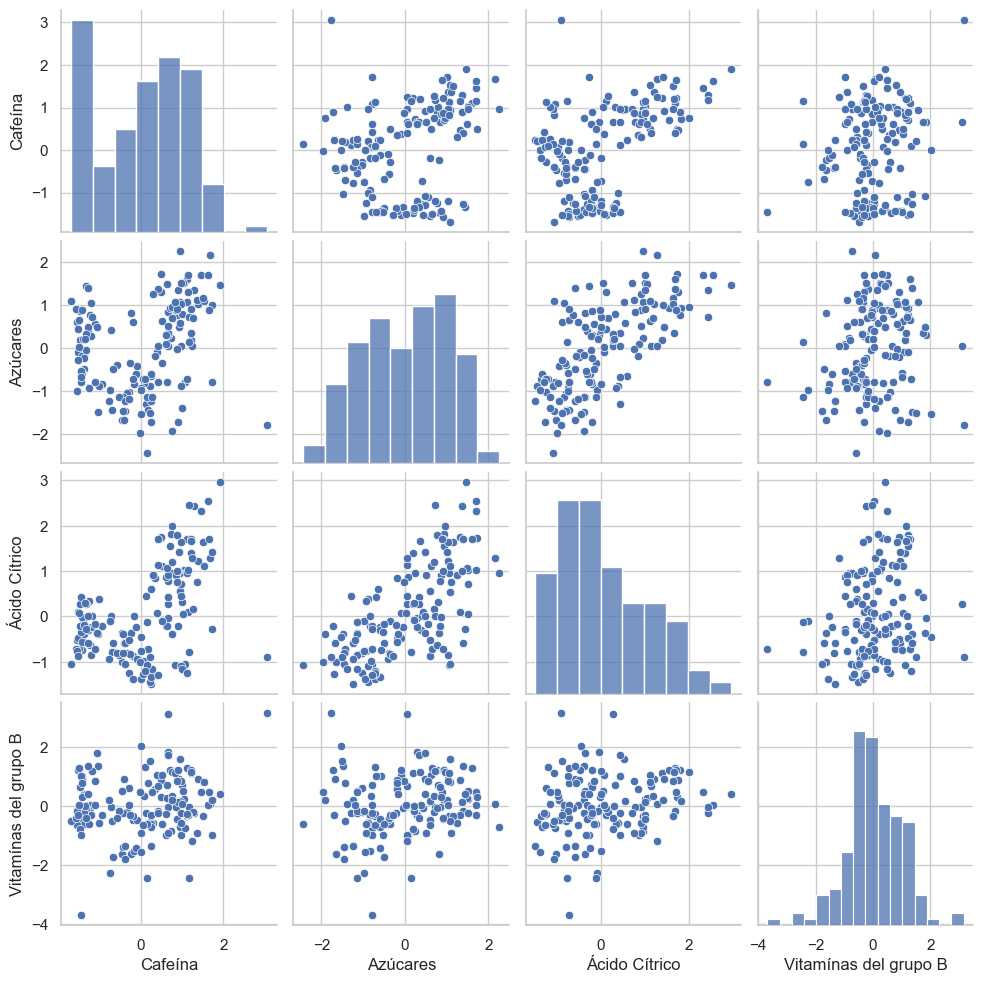

In [21]:
sns.pairplot(X[top_vars])
plt.show()

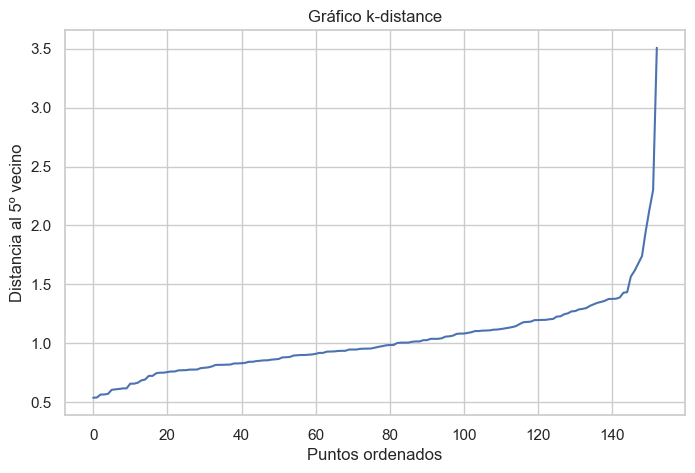

In [22]:
min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, -1])

plt.plot(distances)
plt.title("Gráfico k-distance")
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia al {}º vecino".format(min_samples))
plt.show()

In [23]:
def evaluar_dbscan(X, eps_values, min_samples_values):
    resultados = []

    for eps in eps_values:
        for min_samples in min_samples_values:
            model = DBSCAN(eps=eps, min_samples=min_samples)
            labels = model.fit_predict(X)

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = list(labels).count(-1)

            if n_clusters > 1:
                mask = labels != -1
                if len(set(labels[mask])) > 1:
                    sil = silhouette_score(X[mask], labels[mask])
                else:
                    sil = np.nan
            else:
                sil = np.nan

            resultados.append({
                "eps": eps,
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "n_noise": n_noise,
                "silhouette": sil
            })

    return pd.DataFrame(resultados).sort_values(
        by=["silhouette", "n_clusters"],
        ascending=[False, True]
    )

In [24]:
eps_values = np.arange(0.5, 2.1, 0.1)
min_samples_values = [3, 4, 5, 6, 8]

resultados_dbscan = evaluar_dbscan(X_scaled.values, eps_values, min_samples_values)
resultados_dbscan.head(15)

,eps,min_samples,n_clusters,n_noise,silhouette
13,0.7,6,2,133,0.781232
19,0.8,8,2,124,0.741496
1,0.5,4,3,140,0.619140
12,0.7,5,3,123,0.613097
0,0.5,3,8,125,0.589455
23,0.9,6,3,75,0.586502
18,0.8,6,4,105,0.531753
5,0.6,3,10,107,0.516835
29,1.0,8,3,66,0.515368
6,0.6,4,5,125,0.510183


In [25]:
resultados_dbscan[
    (resultados_dbscan["n_clusters"] >= 3) &
    (resultados_dbscan["n_clusters"] <= 5)
].head(10)

,eps,min_samples,n_clusters,n_noise,silhouette
1,0.5,4,3,140,0.619140
12,0.7,5,3,123,0.613097
23,0.9,6,3,75,0.586502
18,0.8,6,4,105,0.531753
29,1.0,8,3,66,0.515368
6,0.6,4,5,125,0.510183
28,1.0,6,3,45,0.497914
24,0.9,8,3,99,0.489192
34,1.1,8,3,31,0.457382
27,1.0,5,3,33,0.456290


In [26]:
best_eps = 1.1
best_min_samples = 5

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels_db = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db = list(labels_db).count(-1)

print("Clusters:", n_clusters_db)
print("Ruido:", n_noise_db)

Clusters: 2
Ruido: 14


In [27]:
AgglomerativeClustering

sklearn.cluster._agglomerative.AgglomerativeClustering

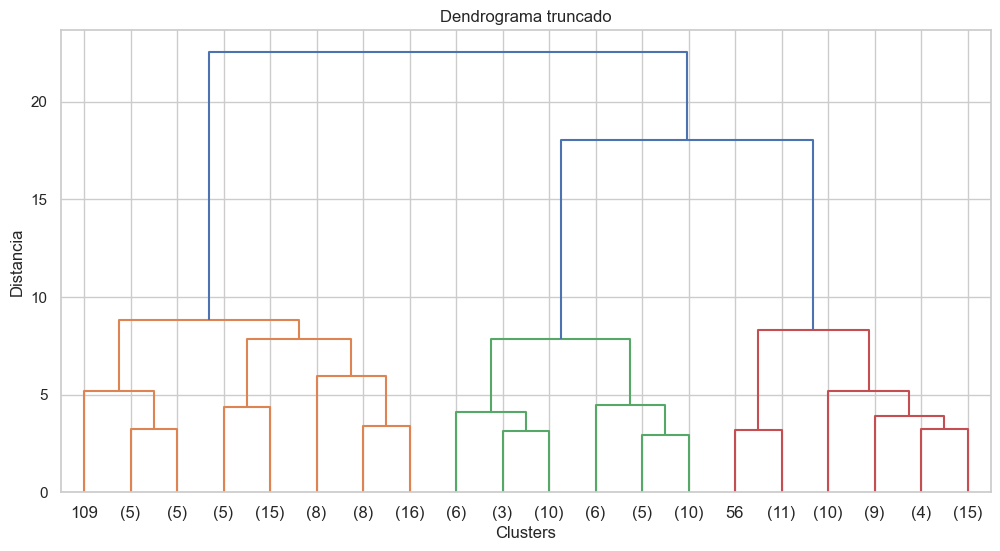

In [28]:
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode="lastp", p=20)
plt.title("Dendrograma truncado")
plt.xlabel("Clusters")
plt.ylabel("Distancia")
plt.show()

In [29]:
def evaluar_agglomerative(X, n_clusters_list, linkage_list):
    resultados = []

    for n_clusters in n_clusters_list:
        for linkage_method in linkage_list:
            if linkage_method == "ward":
                model = AgglomerativeClustering(
                    n_clusters=n_clusters,
                    linkage=linkage_method
                )
            else:
                model = AgglomerativeClustering(
                    n_clusters=n_clusters,
                    linkage=linkage_method
                )

            labels = model.fit_predict(X)

            if len(set(labels)) > 1:
                sil = silhouette_score(X, labels)
            else:
                sil = np.nan

            resultados.append({
                "n_clusters": n_clusters,
                "linkage": linkage_method,
                "silhouette": sil
            })

    return pd.DataFrame(resultados).sort_values(by="silhouette", ascending=False)

In [30]:
resultados_agg = evaluar_agglomerative(
    X_scaled.values,
    n_clusters_list=[3, 4, 5],
    linkage_list=["ward", "complete", "average", "single"]
)

resultados_agg

,n_clusters,linkage,silhouette
0,3,ward,0.376469
10,5,average,0.366557
5,4,complete,0.331009
4,4,ward,0.328786
9,5,complete,0.314675
2,3,average,0.296189
8,5,ward,0.293075
6,4,average,0.280008
1,3,complete,0.203330
7,4,single,0.132007


In [31]:
agg = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg.fit_predict(X_scaled)

print("Número de clusters:", len(set(labels_agg)))
print("Silhouette:", silhouette_score(X_scaled, labels_agg))

Número de clusters: 4
Silhouette: 0.3287864127818098


In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

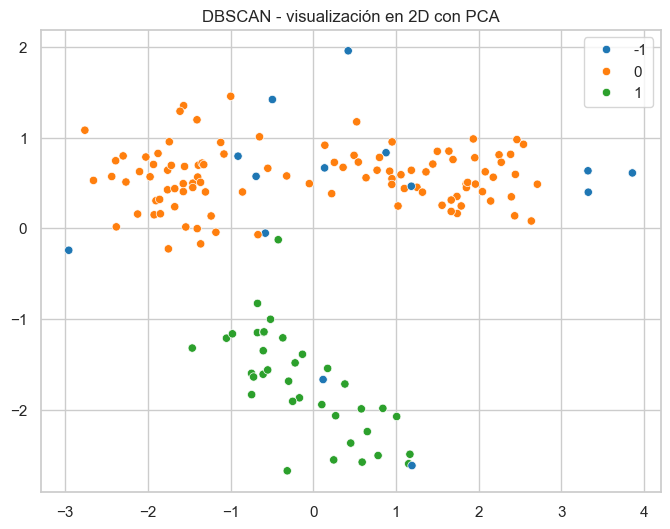

In [33]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_db, palette="tab10")
plt.title("DBSCAN - visualización en 2D con PCA")
plt.show()

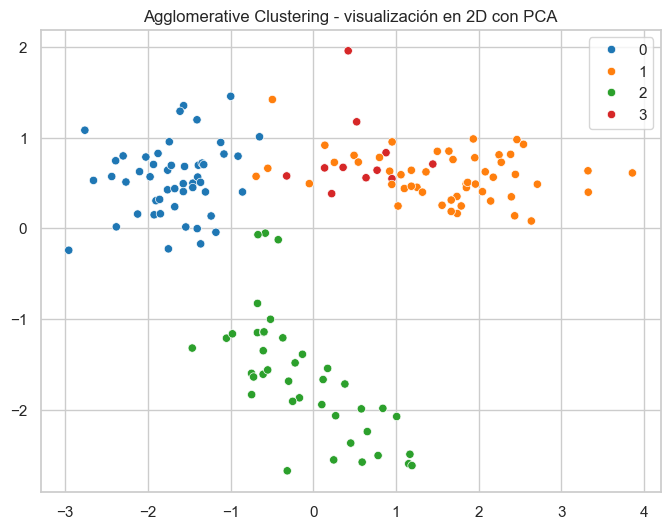

In [34]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_agg, palette="tab10")
plt.title("Agglomerative Clustering - visualización en 2D con PCA")
plt.show()

In [35]:
df_db = X.copy()
df_db["cluster"] = labels_db

df_db.groupby("cluster").mean()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
cluster,,,,,
-1,0.224231,-0.029043,0.663351,0.419328,0.287558
0,-0.068163,0.004925,0.447547,0.171962,-0.402052
1,0.189552,0.155617,-1.363959,-0.314984,0.851114


In [36]:
df_agg = X.copy()
df_agg["cluster"] = labels_agg

df_agg.groupby("cluster").mean()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
cluster,,,,,
0,-1.106573,-0.397397,-0.090226,-0.755086,-0.997113
1,0.946352,0.082324,1.032502,1.165681,0.274094
2,0.225181,0.123052,-1.308058,-0.310997,0.814750
3,0.004851,1.488161,0.856843,0.165644,-0.339331


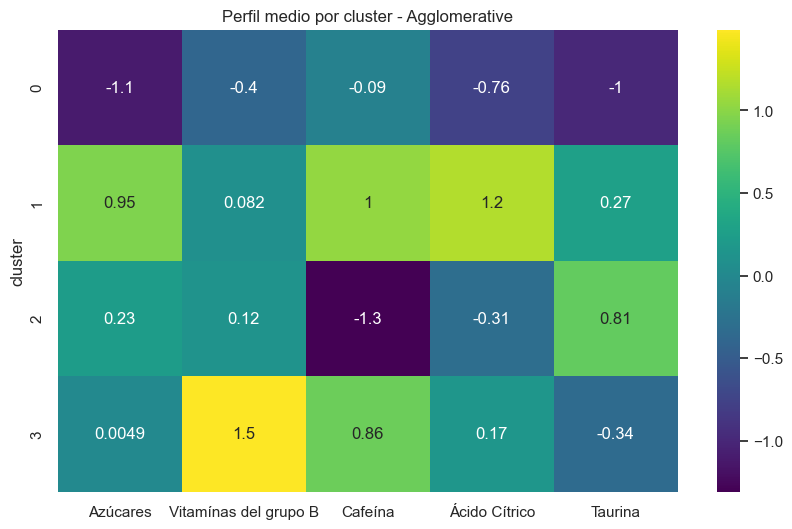

In [37]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_agg.groupby("cluster").mean(), annot=True, cmap="viridis")
plt.title("Perfil medio por cluster - Agglomerative")
plt.show()

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

In [38]:
new_df = pd.read_csv("./data/new_experiments.csv", sep="|")
new_df.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583


In [39]:
new_X = new_df[X.columns].copy()
new_X.head()

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583


In [40]:
new_X_scaled = scaler.transform(new_X)

In [41]:
train_clusters = pd.DataFrame(X_scaled, columns=X.columns)
train_clusters["cluster"] = labels_agg

centroides = train_clusters.groupby("cluster").mean()
centroides

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
cluster,,,,,
0,-1.100682,-0.437857,-0.126536,-0.830007,-1.023283
1,0.906434,0.045381,0.955591,1.079028,0.341638
2,0.201355,0.086407,-1.300326,-0.388631,0.922152
3,-0.014058,1.461522,0.786284,0.085099,-0.317009


In [42]:
from scipy.spatial.distance import cdist

distancias = cdist(new_X_scaled, centroides.values, metric="euclidean")
new_labels = centroides.index[np.argmin(distancias, axis=1)]

In [43]:
new_df["cluster_asignado"] = new_labels
new_df

,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina,cluster_asignado
0,1.481555,0.305159,1.366128,2.239039,0.731870,1
1,0.616869,0.890014,0.583034,0.312420,-0.665332,3
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782,0
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240,0
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583,2
5,0.962743,-0.243142,-1.354622,-0.420013,1.956043,2


In [44]:
new_df["cluster_asignado"].value_counts().sort_index()

cluster_asignado
0    2
1    1
2    2
3    1
Name: count, dtype: int64

c:\Users\sarar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


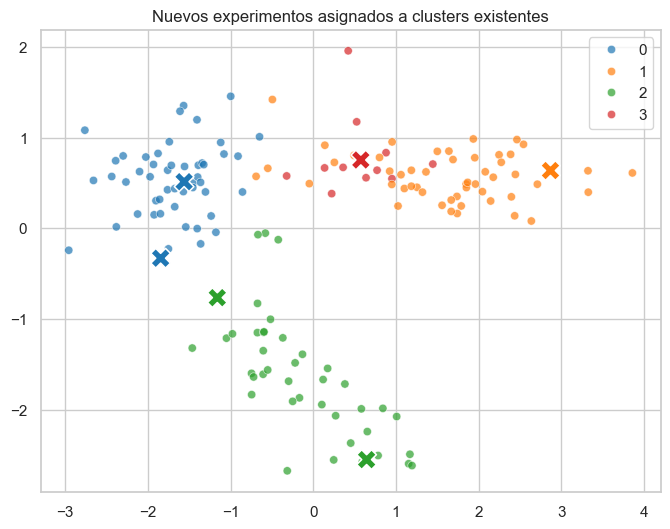

In [45]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)
new_pca = pca.transform(new_X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_agg, palette="tab10", alpha=0.7)
sns.scatterplot(x=new_pca[:, 0], y=new_pca[:, 1], hue=new_labels, palette="tab10", marker="X", s=200, legend=False)

plt.title("Nuevos experimentos asignados a clusters existentes")
plt.show()

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.